In [1]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')
import numpy as np
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers.models import AutoencoderKLFlux2
from diffusers import DDPMScheduler, EulerDiscreteScheduler, FlowMatchEulerDiscreteScheduler
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

device = "cuda"

In [2]:
text_encoder = CLIPTextModel.from_pretrained("../../stable-diffusion-xl-base-1.0/text_encoder").to("cuda", torch.float32)
tokenizer = CLIPTokenizer.from_pretrained("../../stable-diffusion-xl-base-1.0/tokenizer")
vae = AutoencoderKLFlux2.from_pretrained("../../FLUX.2-klein-4B/vae", device=device).to(device)

flow_scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained("../../FLUX.2-klein-4B/scheduler", device=device)

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [3]:
def encode_text_batch_enc1(text_batch):
    inputs = tokenizer(
        text_batch,
        padding="max_length",
        truncation=True,
        max_length=tokenizer.model_max_length,
        return_tensors="pt"
    ).to("cuda")
    
    with torch.no_grad():
        embed = text_encoder(inputs.input_ids, output_hidden_states=True, return_dict=True)
        text_embeds = embed.pooler_output

    return text_embeds


latents_bn_mean = vae.bn.running_mean.view(1, -1, 1, 1).to(device)
latents_bn_std = torch.sqrt(vae.bn.running_var.view(1, -1, 1, 1) + vae.config.batch_norm_eps).to(device)

def patchify_latents(latents):
    batch_size, num_channels_latents, height, width = latents.shape
    latents = latents.view(
        batch_size, num_channels_latents, height // 2, 2, width // 2, 2
    )
    latents = latents.permute(0, 1, 3, 5, 2, 4)
    latents = latents.reshape(
        batch_size, num_channels_latents * 4, height // 2, width // 2
    )
    return latents

def unpatchify_latents(latents):
    batch_size, num_channels_latents, height, width = latents.shape
    latents = latents.reshape(
        batch_size, num_channels_latents // (2 * 2), 2, 2, height, width
    )
    latents = latents.permute(0, 1, 4, 2, 5, 3)
    latents = latents.reshape(
        batch_size, num_channels_latents // (2 * 2), height * 2, width * 2
    )
    return latents

In [4]:
def make_group_norm(channels: int, max_groups: int = 32, eps: float = 1e-6) -> nn.GroupNorm:
    groups = min(max_groups, channels)
    while channels % groups != 0 and groups > 1:
        groups -= 1
    return nn.GroupNorm(groups, channels, eps=eps)


class AttentionBlock(nn.Module):
    def __init__(
        self, 
        channels: int, 
        num_heads: int = 8, 
        head_dim: int = 64
    ):
        super().__init__()
        self.channels = channels
        self.num_heads = num_heads
        self.head_dim = head_dim
        self.attn_dim = num_heads * head_dim
        
        self.norm = make_group_norm(channels)

        self.to_q = nn.Conv2d(channels, self.attn_dim, kernel_size=1, stride=1, padding=0)
        self.to_k = nn.Conv2d(channels, self.attn_dim, kernel_size=1, stride=1, padding=0)
        self.to_v = nn.Conv2d(channels, self.attn_dim, kernel_size=1, stride=1, padding=0)

        self.to_out = nn.Conv2d(self.attn_dim, channels, kernel_size=1, stride=1, padding=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        
        b, c, H, W = x.shape 
        
        h = self.norm(x) 
        
        q = self.to_q(h)
        k = self.to_k(h)
        v = self.to_v(h)

        q = q.view(b, self.num_heads, self.head_dim, H * W).permute(0, 1, 3, 2)
        k = k.view(b, self.num_heads, self.head_dim, H * W).permute(0, 1, 3, 2)
        v = v.view(b, self.num_heads, self.head_dim, H * W).permute(0, 1, 3, 2)
        
        attn_out = F.scaled_dot_product_attention(q, k, v)
 
        attn_out = attn_out.permute(0, 1, 3, 2).reshape(b, self.attn_dim, H, W)

        out = self.to_out(attn_out)
        
        return out + residual


class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int = 128, max_period: int = 10000):
        super().__init__()
        self.dim = dim
        self.max_period = max_period

    def forward(self, timesteps: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        timesteps = timesteps.float()

        freqs = torch.exp(
            -torch.log(torch.tensor(float(self.max_period), device=timesteps.device))
            * torch.arange(half, device=timesteps.device, dtype=timesteps.dtype)
            / half
        )
        args = timesteps[:, None] * freqs[None]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))

        return emb


class ConditioningEncoder(nn.Module):
    """
    Fuses timestep and text into a single conditioning vector.
    """
    def __init__(self, time_dim: int = 128, text_dim: int = 768, cond_dim: int = 256):
        super().__init__()
        self.time_embed = SinusoidalTimeEmbedding(time_dim)

        self.time_proj = nn.Sequential(
            nn.Linear(time_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )

        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )

    def forward(self, timestep: torch.Tensor, text_embed: torch.Tensor) -> torch.Tensor:
        time_vec = self.time_proj(self.time_embed(timestep))
        text_vec = self.text_proj(text_embed)
        return time_vec + text_vec


class ConditionedResidualBlock(nn.Module):
    """
    SDXL-style residual block:
      GN -> SiLU -> Conv
      + condition (scale/shift)
      GN -> SiLU -> Dropout -> Conv
      + skip connection
    """
    def __init__(
        self,
        input_channels: int,
        output_channels: int,
        cond_dim: int = 256,
        dropout: float = 0.0,
    ):
        super().__init__()

        self.norm1 = make_group_norm(input_channels)
        self.conv1 = nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1)

        self.cond_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(cond_dim, 2 * output_channels),
        )

        self.norm2 = make_group_norm(output_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1)

        if input_channels != output_channels:
            self.skip = nn.Conv2d(input_channels, output_channels, kernel_size=1, bias=False)
        else:
            self.skip = nn.Identity()

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        residual = self.skip(x)

        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        scale_shift = self.cond_proj(cond)
        scale, shift = scale_shift.chunk(2, dim=1)

        h = self.norm2(h)
        h = h * (1 + scale[:, :, None, None]) + shift[:, :, None, None]
        h = F.silu(h)
        h = self.dropout(h)
        h = self.conv2(h)

        return h + residual


class ResAttnStage(nn.Module):
    def __init__(
        self,
        input_channels: int,
        output_channels: int,
        cond_dim: int = 256,
        dropout: float = 0.0,
        use_attention: bool = False,
        num_heads: int = 4,
    ):
        super().__init__()
        self.res = ConditionedResidualBlock(
            input_channels=input_channels,
            output_channels=output_channels,
            cond_dim=cond_dim,
            dropout=dropout,
        )
        self.attn = AttentionBlock(output_channels, num_heads=num_heads) if use_attention else nn.Identity()

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        x = self.res(x, cond)
        x = self.attn(x)
        return x


class DownStage(nn.Module):
    def __init__(
        self,
        input_channels: int,
        output_channels: int,
        cond_dim: int = 256,
        dropout: float = 0.0,
        num_blocks: int = 1,
        use_attention: bool = False,
        num_heads: int = 4,
    ):
        super().__init__()

        attn_flags = [use_attention] * num_blocks

        self.blocks = nn.ModuleList()
        for i in range(num_blocks):
            in_ch = input_channels if i == 0 else output_channels
            self.blocks.append(
                ResAttnStage(
                    input_channels=in_ch,
                    output_channels=output_channels,
                    cond_dim=cond_dim,
                    dropout=dropout,
                    use_attention=attn_flags[i],
                    num_heads=num_heads,
                )
            )

        self.downsample = nn.AvgPool2d(2)

    def forward(self, x: torch.Tensor, cond: torch.Tensor):
        for block in self.blocks:
            x = block(x, cond)
        skip = x
        x = self.downsample(x)
        return x, skip


class UpStage(nn.Module):
    def __init__(
        self,
        input_channels: int,
        skip_channels: int,
        output_channels: int,
        cond_dim: int = 256,
        dropout: float = 0.0,
        num_blocks: int = 1,
        use_attention: bool = False,
        num_heads: int = 4,
    ):
        super().__init__()

        attn_flags = [use_attention] * num_blocks

        self.upsample = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)

        self.blocks = nn.ModuleList()
        for i in range(num_blocks):
            in_ch = (input_channels + skip_channels) if i == 0 else output_channels
            self.blocks.append(
                ResAttnStage(
                    input_channels=in_ch,
                    output_channels=output_channels,
                    cond_dim=cond_dim,
                    dropout=dropout,
                    use_attention=attn_flags[i],
                    num_heads=num_heads,
                )
            )

    def forward(self, x: torch.Tensor, skip: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        x = self.upsample(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

        x = torch.cat([x, skip], dim=1)

        for block in self.blocks:
            x = block(x, cond)

        return x


class UNet(nn.Module):
    def __init__(
        self,
        sample_channels: int = 32,
        base_channels: int = 256,
        text_dim: int = 768,
        time_dim: int = 512,
        cond_dim: int = 1024,
        dropout: float = 0.01,
        num_heads: int = 16,
    ):
        super().__init__()

        self.conditioning = ConditioningEncoder(
            time_dim=time_dim,
            text_dim=text_dim,
            cond_dim=cond_dim,
        )

        self.in_conv = nn.Conv2d(sample_channels, base_channels, kernel_size=1, padding=0)

        self.down_stages = nn.ModuleList([
            DownStage(
                input_channels=base_channels,
                output_channels=base_channels,
                cond_dim=cond_dim,
                dropout=dropout,
                num_blocks=2,
                use_attention=False,
                num_heads=num_heads,
            ),
            DownStage(
                input_channels=base_channels,
                output_channels=base_channels * 2,
                cond_dim=cond_dim,
                dropout=dropout,
                num_blocks=4,
                use_attention=True,
                num_heads=num_heads,
            ),
        ])

        self.mid_stages = nn.ModuleList([
            ResAttnStage(
                input_channels=base_channels * 2,
                output_channels=base_channels * 2,
                cond_dim=cond_dim,
                dropout=dropout,
                use_attention=True,
                num_heads=num_heads,
            )
            for _ in range(8)
        ])

        self.up_stages = nn.ModuleList([
            UpStage(
                input_channels=base_channels * 2,
                skip_channels=base_channels * 2,
                output_channels=base_channels,
                cond_dim=cond_dim,
                dropout=dropout,
                num_blocks=4,
                use_attention=True,
                num_heads=num_heads,
            ),
            UpStage(
                input_channels=base_channels,
                skip_channels=base_channels,
                output_channels=base_channels,
                cond_dim=cond_dim,
                dropout=dropout,
                num_blocks=2,
                use_attention=False,
                num_heads=num_heads,
            ),
        ])

        self.out_conv = nn.Conv2d(base_channels, sample_channels, kernel_size=1, padding=0)

    def forward(self, sample: torch.Tensor, timestep: torch.Tensor, text_embed: torch.Tensor) -> torch.Tensor:
        cond = self.conditioning(timestep, text_embed)

        x = self.in_conv(sample)

        skips = []
        for down in self.down_stages:
            x, skip = down(x, cond)
            skips.append(skip)

        for mid in self.mid_stages:
            x = mid(x, cond)

        for up in self.up_stages:
            x = up(x, skips.pop(), cond)

        x = self.out_conv(x)
        return x

In [5]:
unet = UNet()
unet = unet.to(device)
state_dict = torch.load('../../trained_models/flow_unet_l-1.1.pth', weights_only=True)
unet.load_state_dict(state_dict)
unet = unet.eval()

In [6]:
embeds = torch.load("../../precomputes/embeds_enc1.pt")

In [7]:
print(embeds.shape)

torch.Size([591753, 768])


In [8]:
batch_size = 128
steps = 32
mu = 2.0
cfg = 7.0

num_batches = 100000 // batch_size
num_pairs = batch_size * num_batches

all_embeds = torch.empty(
    (num_pairs, 768),
    dtype=torch.float16,
)

all_noise = torch.empty(
    (num_pairs, 32, 32, 32),
    dtype=torch.float16,
)

all_latents = torch.empty(
    (num_pairs, 32, 32, 32),
    dtype=torch.float16,
)

In [9]:
for i in tqdm(range(num_batches)):
    indices = torch.randint(high=len(embeds), size=(batch_size,))
    embeds_batch = embeds[indices].to(device).float()
    negative_embeds_batch = torch.zeros_like(embeds_batch)
    noise_batch = torch.normal(0, 1, (batch_size, 32, 32, 32), dtype=torch.float32, device="cuda")

    flow_scheduler.set_timesteps(steps, mu=mu)
    latents = noise_batch.clone()

    with torch.no_grad():
        for t in flow_scheduler.timesteps:
            latent_model_input = latents
            t = t.to(device).view(1)
            predicted_noise = unet(sample=latent_model_input, timestep=t, text_embed=embeds_batch)
            negative_predicted_noise = unet(sample=latent_model_input, timestep=t, text_embed=negative_embeds_batch)
            predicted_noise_cfg = negative_predicted_noise + (predicted_noise - negative_predicted_noise) * cfg
            latents = flow_scheduler.step(predicted_noise_cfg, t, latents).prev_sample

    idx = i * batch_size

    all_embeds[idx:idx+batch_size] = embeds_batch.cpu().to(torch.float16)
    all_noise[idx:idx+batch_size] = noise_batch.cpu().to(torch.float16)
    all_latents[idx:idx+batch_size] = latents.cpu().to(torch.float16)

100%|██████████| 781/781 [1:39:09<00:00,  7.62s/it]


In [10]:
torch.save(all_embeds, "../../precomputes/rectification/embeds2.pt")
torch.save(all_noise, "../../precomputes/rectification/noise2.pt")
torch.save(all_latents, "../../precomputes/rectification/latents2.pt")

In [11]:
all_embeds = torch.load("../../precomputes/rectification/embeds.pt")
all_noise = torch.load("../../precomputes/rectification/noise.pt")
all_latents = torch.load("../../precomputes/rectification/latents.pt")

In [20]:
latents = all_latents[124:128].cuda().float()

latents = patchify_latents(latents)
latents = latents * latents_bn_std
latents = latents + latents_bn_mean
latents = unpatchify_latents(latents)
with torch.no_grad():
    images = (vae.decode(latents).sample + 1.0) / 2.0

images = images.permute((0, 2, 3, 1)).float().cpu().numpy()
images = np.clip(images, 0, 1)

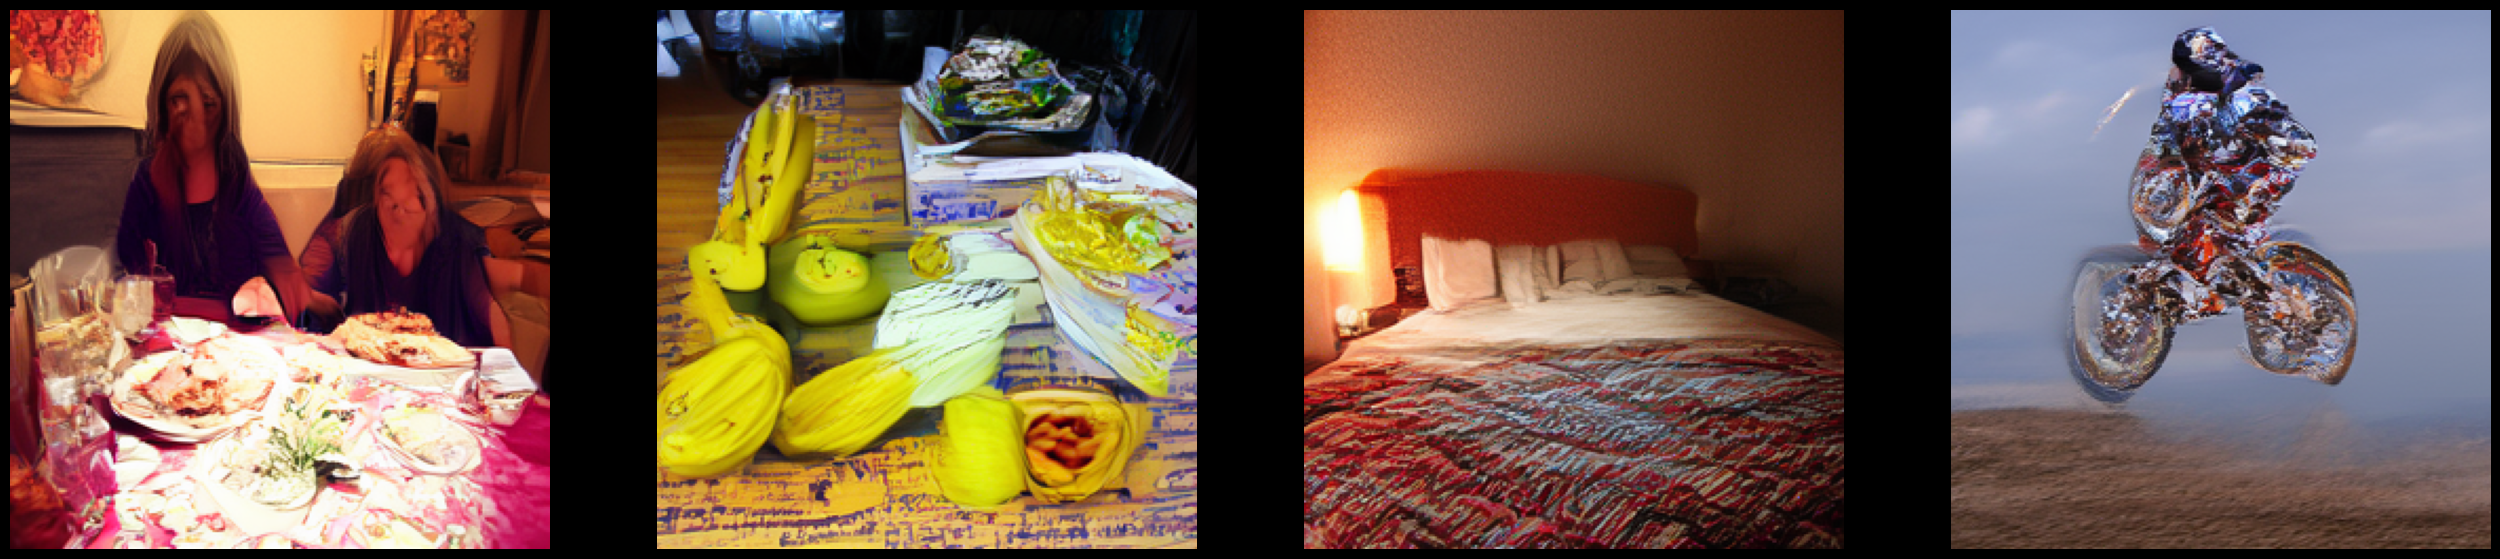

In [21]:
fig, ax = plt.subplots(1, len(images), figsize=(32, 8))
for i in range(len(images)):
    ax[i].imshow(images[i])
    ax[i].axis("off")

plt.show()